# Linear Regression From Scratch

## Project Goal
The goal of this project is to implement Linear Regression from scratch using Python and NumPy, without using machine learning libraries.

We will:
- Create a simple dataset
- Implement the prediction function
- Implement the Mean Squared Error (MSE) cost function
- Train the model using Gradient Descent
- Visualize the regression line and evaluate the results

This project helps understand how Linear Regression works internally.

## Import Libraries

In [40]:
import numpy as np
import matplotlib.pyplot as plt

## Step 1 — Building the Class Skeleton

We use a class because it lets us **store the learned weights inside the object**,
just like scikit-learn does. Once trained, we can call `.predict()` anytime without
passing weights around manually.

Our class needs:
- `learning_rate` → controls how big each update step is during training
- `n_iterations` → how many times we loop and improve the weights
- `weights` and `bias` → start as None, get initialized when we see the data

In [41]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def _mse(self, y_true, y_pred):
        return np.mean((y_pred - y_true) ** 2)
    
    def predict(self, X):
        return np.dot(X, self.weights).flatten() + self.bias
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for _ in range(self.n_iterations):
            y_pred = self.predict(X)
            dw = (2 / n_samples) * np.sum((y_pred - y).reshape(-1, 1) * X, axis=0)
            db = (2 / n_samples) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            self.loss_history.append(self._mse(y, y_pred))

## Step 2 — Preparing & Visualizing the Data

Before training anything, we always **look at our data first**.
This helps us understand:
- The shape and structure of our inputs
- Whether a linear relationship actually exists
- If there are any obvious outliers

### Data Shape Convention
Linear regression expects:
- `X` shape → `(n_samples, n_features)` — each row is one sample
- `y` shape → `(n_samples,)` — one target value per sample

We use `.reshape(-1, 1)` to convert a flat array into the right shape.
The `-1` tells NumPy to figure out that dimension automatically.

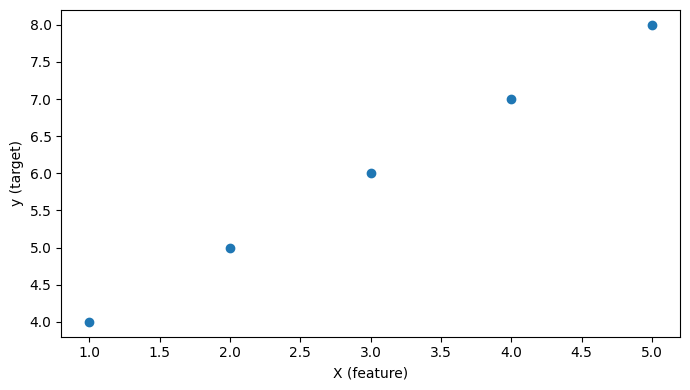

In [42]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([4, 5, 6, 7, 8])

plt.figure(figsize=(7, 4))
plt.scatter(X, y)
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.tight_layout()
plt.show()

## Step 3 — The Cost Function (Mean Squared Error)

We need a way to measure **how wrong our model is** at any point during training.
We use **Mean Squared Error (MSE)**:

**MSE = (1/n) · Σ(ŷᵢ - yᵢ)²**

- Subtract prediction from truth → get the error
- Square it → so negatives don't cancel positives
- Average over all samples → one single number representing total error

**Goal: make this number as small as possible.**

In [43]:
model = LinearRegression()

model.weights = np.zeros(1)
model.bias = 0
print("MSE (w=0, b=0): ", model._mse(y, model.predict(X)))

model.weights = np.array([1])
model.bias = 3
print("MSE (w=1, b=3): ", model._mse(y, model.predict(X)))

MSE (w=0, b=0):  38.0
MSE (w=1, b=3):  0.0


## Step 4 — Gradient Descent

We know how to measure our error (MSE). Now we need a way to **automatically improve** our weights and bias to reduce that error.

This is where **Gradient Descent** comes in.

### The Math
We need the **derivatives** of MSE with respect to `w` and `b`.
These tell us which direction to move each weight.

**dMSE/dw = (2/n) · Σ(ŷᵢ - yᵢ) · xᵢ**

**dMSE/db = (2/n) · Σ(ŷᵢ - yᵢ)**

Then we **update** the weights by stepping in the opposite direction of the gradient:

**w = w - lr · dw**

**b = b - lr · db**

- `lr` (learning rate) → controls how big each step is
- We subtract because we want to go **downhill** (reduce error)

### The Loop
We repeat this process for `n_iterations` — each time getting slightly better weights.

In [44]:
model = LinearRegression(learning_rate=0.01, n_iterations=10000)
model.fit(X, y)

print(f"learned Weight:  {model.weights[0]:.2f}")
print(f"Learned bias:  {model.bias:.2f}")
print(f"MSE:  {model.loss_history[-1]:.2f}")

learned Weight:  1.00
Learned bias:  3.00
MSE:  0.00


## Step 5 — Visualizing the Fitted Line

Now that our model has learned `w` and `b`, let's visually confirm it worked.
We'll plot:
1. **The original data points** — the ground truth
2. **The fitted line** — what our model learned
3. **The loss curve** — how MSE dropped during training

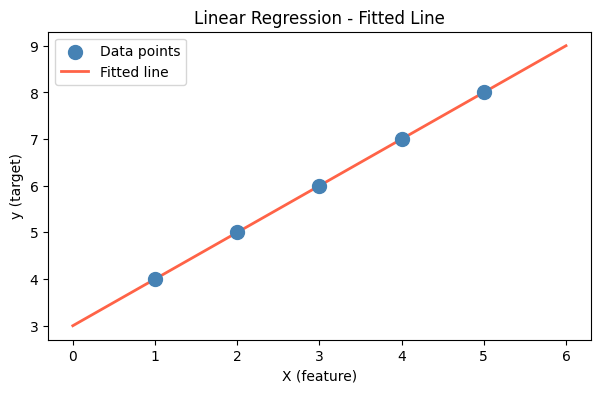

In [45]:
X_line = np.linspace(0, 6, 100).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, color="steelblue", s=100, zorder=5, label="Data points")
plt.plot(X_line, y_line, color="tomato", linewidth=2, label="Fitted line")
plt.title("Linear Regression - Fitted Line")
plt.xlabel("X (feature)")
plt.ylabel("y (target)")
plt.legend()

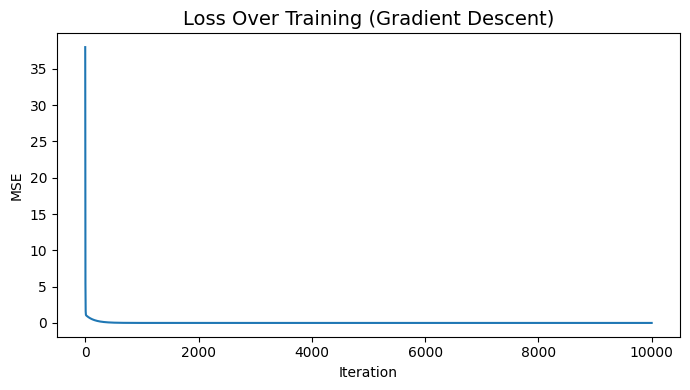

In [46]:
plt.figure(figsize=(7, 4))
plt.plot(model.loss_history)

plt.title("Loss Over Training (Gradient Descent)", fontsize=14)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.tight_layout()
plt.show()

## Step 6 — Testing on New Unseen Data

Now let's properly test our model on unseen data.

The correct ML workflow is:
1. **Train** on training data → model learns `w` and `b`
2. **Test** on unseen data from the **same distribution** → evaluate how well it generalizes

Both training and test data must follow the same underlying rule.

In [47]:
# Train Data
X_train = np.array([1, 2, 4, 6, 8]).reshape(-1, 1)
y_train = np.array(X_train * 2 + 3).flatten()

# Test Data
X_test = np.array([3, 5, 7, 9, 11]).reshape(-1, 1)
y_test = np.array(X_test * 2 + 3).flatten()

model = LinearRegression(learning_rate=0.01, n_iterations=100000)
model.fit(X_train, y_train)

print(f"weight:  {model.weights[0]:.2f}")
print(f"bias:  {model.bias:.2f}")
print(f"Train MSE: {model.loss_history[-1]:.2f}\n")

y_pred_test = model.predict(X_test)
print(f"{'X':>6}  {'True y':>8}  {'Predicted y':>12}  {'Error':>8}")
print("-" * 42)
for i in range(len(X_test)):
    error = abs(y_test[i] - y_pred_test[i])
    print(f"{X_test[i][0]:>6}  {y_test[i]:>8}  {y_pred_test[i]:>12.6f}  {error:>8.6f}\n")
print(f"Test MSE: {model._mse(y_test, y_pred_test):.2f}")


weight:  2.00
bias:  3.00
Train MSE: 0.00

     X    True y   Predicted y     Error
------------------------------------------
     3         9      9.000000  0.000000

     5        13     13.000000  0.000000

     7        17     17.000000  0.000000

     9        21     21.000000  0.000000

    11        25     25.000000  0.000000

Test MSE: 0.00


[]

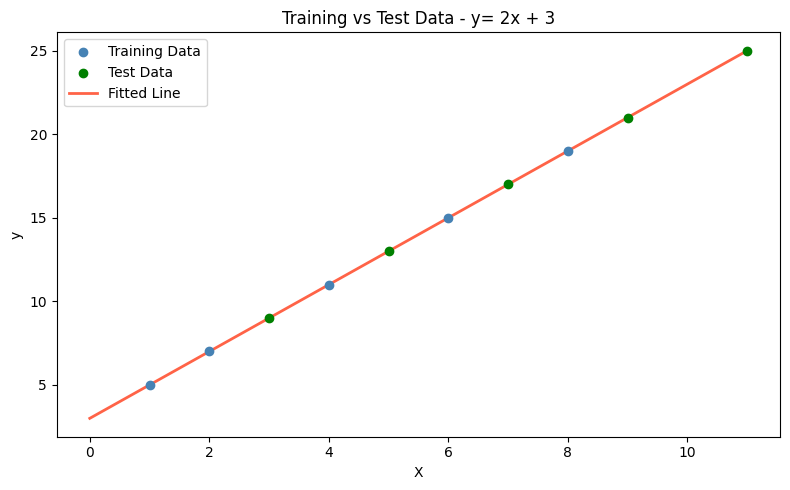

In [48]:
plt.figure(figsize=(8, 5))

X_full = np.linspace(0, 11, 100).reshape(-1, 1)
plt.scatter(X_train, y_train, color="steelblue", zorder=5, label="Training Data")
plt.scatter(X_test, y_test, color="green", zorder=5, label="Test Data")
plt.plot(X_full, model.predict(X_full), color="tomato", linewidth="2", label="Fitted Line")
plt.title("Training vs Test Data - y= 2x + 3")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.plot()



# 📈 Linear Regression From Scratch — Full Summary

In this notebook we built a Linear Regression model from scratch using only NumPy.

## What We Built
| Step | What |
|------|------|
| Step 1 | Class skeleton — `__init__` |
| Step 2 | Data preparation & visualization |
| Step 3 | Cost function — MSE |
| Step 4 | Gradient descent — `fit()` |
| Step 5 | Visualizing the fitted line |
| Step 6 | Testing on unseen data |

## The Math Behind It
| Concept | Formula |
|---------|---------|
| Prediction | ŷ = Xw + b |
| Cost (MSE) | (1/n) · Σ(ŷ - y)² |
| Gradient w | (2/n) · Σ(ŷ - y) · x |
| Gradient b | (2/n) · Σ(ŷ - y) |
| Weight update | w = w - lr · dw |
| Bias update | b = b - lr · db |